# Analysis

#### 1. Imports

In [1]:
import pandas as pd
import ast
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import chi2_contingency
import numpy as np

#### 2. Loading the lemmatized corpus

In [2]:
df = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/output_files/09_h1_lemmatized.csv")
df["tokens"] = df["tokens"].apply(ast.literal_eval)

#### 3. Extracting the issue number and assign the volume group

In [3]:
def get_issue_number(filepath):
    match = re.search(r"heresies_(\d+)_combined", filepath)
    return int(match.group(1)) if match else None

def get_volume(issue_nr):
    if issue_nr <= 4:
        return "Vol1_late1970s"
    elif issue_nr <= 8:
        return "Vol2_early1980s"
    elif issue_nr <= 12:
        return "Vol3_late1980s"
    elif issue_nr <= 16:
        return "Vol4_early1990s"
    elif issue_nr <= 20:
        return "Vol5"
    elif issue_nr <= 24:
        return "Vol6"
    else:
        return "Vol7"

df["issue"]  = df["source_file"].apply(get_issue_number)
df["volume"] = df["issue"].apply(get_volume)

# only work with issues 1-14 for now
df = df[df["issue"] <= 14]

print(df["volume"].value_counts())
print(f"Total issues loaded: {df['issue'].nunique()}")
print(f"Issues present: {sorted(df['issue'].unique())}")

volume
Vol2_early1980s    4413
Vol1_late1970s     3905
Vol3_late1980s     3738
Vol4_early1990s    1007
Name: count, dtype: int64
Total issues loaded: 14
Issues present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]


#### 4. Create one text string per volume

In [4]:
# join all tokens per volume into one string
# this is needed for TF-IDF and keyword analysis

volume_texts = df.groupby("volume")["tokens"].apply(
    lambda x: " ".join([token for tokens in x for token in tokens])
)

print(volume_texts.index.tolist())

['Vol1_late1970s', 'Vol2_early1980s', 'Vol3_late1980s', 'Vol4_early1990s']


#### 5. Relative Frequency for key feminist terms
Using this: https://www.geeksforgeeks.org/python/python-frequency-of-each-character-in-string/

In [5]:
# these are your expected keywords from your notes
key_terms = ["body", "woman", "difference", "language", 
             "representation", "identity", "power", "sexuality",
             "nature", "culture", "construction", "discourse"]

results = []

for volume, text in volume_texts.items():
    tokens = text.split()
    total  = len(tokens)
    for term in key_terms:
        freq    = tokens.count(term)
        rel_freq = (freq / total) * 1000   # per 1000 words
        results.append({
            "volume": volume,
            "term":   term,
            "relative_frequency": rel_freq
        })

df_freq = pd.DataFrame(results)
print(df_freq.head(10))

           volume            term  relative_frequency
0  Vol1_late1970s            body            1.280125
1  Vol1_late1970s           woman           23.654478
2  Vol1_late1970s      difference            0.333946
3  Vol1_late1970s        language            0.333946
4  Vol1_late1970s  representation            0.111315
5  Vol1_late1970s        identity            0.166973
6  Vol1_late1970s           power            1.001837
7  Vol1_late1970s       sexuality            0.222630
8  Vol1_late1970s          nature            0.445261
9  Vol1_late1970s         culture            1.614070


#### 6. Line Chart of Key Terms over time
Using this: https://www.geeksforgeeks.org/python/line-chart-in-matplotlib-python/

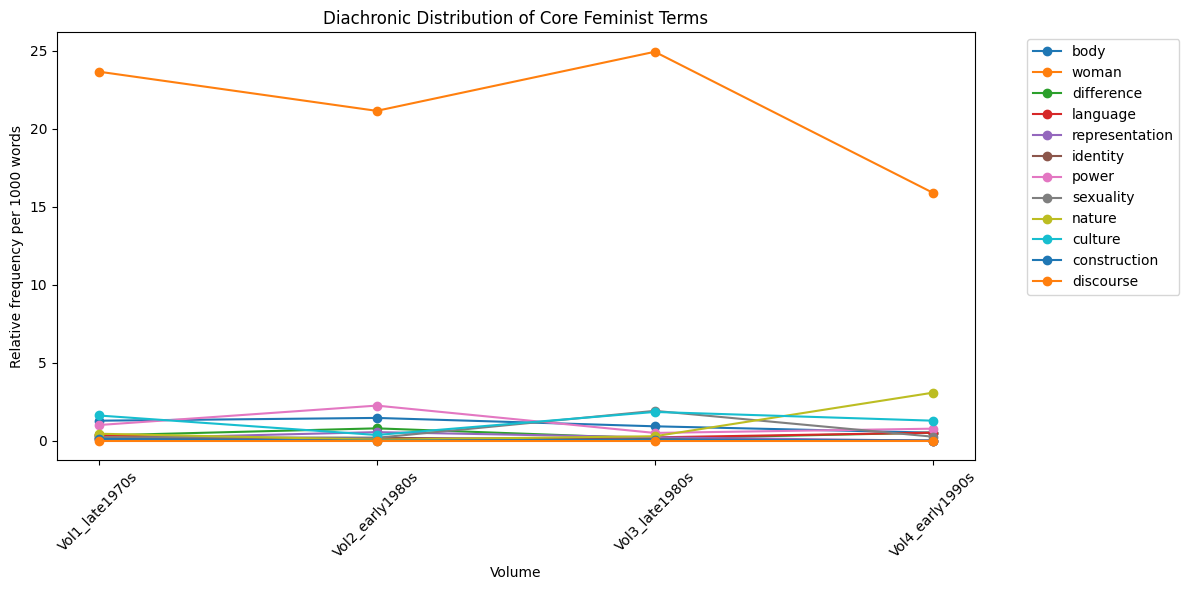

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

for term in key_terms:
    term_data = df_freq[df_freq["term"] == term]
    ax.plot(term_data["volume"], term_data["relative_frequency"], marker="o", label=term)

ax.set_xlabel("Volume")
ax.set_ylabel("Relative frequency per 1000 words")
ax.set_title("Diachronic Distribution of Core Feminist Terms")
ax.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph1_frequency.png")
plt.show()

#### 7. TF-IDF per volume
Using this: https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=50)
tfidf_matrix = vectorizer.fit_transform(volume_texts.values)
feature_names = vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=volume_texts.index,
    columns=feature_names
)

print(df_tfidf)

                     also       art    artist     begin     black     child  \
volume                                                                        
Vol1_late1970s   0.077200  0.319830  0.119739  0.056719  0.007878  0.067747   
Vol2_early1980s  0.049828  0.088584  0.079356  0.071974  0.108884  0.036910   
Vol3_late1980s   0.057121  0.118322  0.055081  0.038761  0.071401  0.044881   
Vol4_early1990s  0.081278  0.144494  0.108370  0.054185  0.036123  0.081278   

                 collective      come     could  feminist  ...       use  \
volume                                                     ...             
Vol1_late1970s     0.045690  0.089805  0.051992  0.138646  ...  0.088229   
Vol2_early1980s    0.084893  0.086738  0.071974  0.094120  ...  0.059056   
Vol3_late1980s     0.040801  0.083642  0.040801  0.128522  ...  0.075481   
Vol4_early1990s    0.081278  0.081278  0.090309  0.207710  ...  0.063216   

                     want       way      well     woman      work   

#### 8. Keyword comparison table

In [8]:
# show top 10 distinctive terms per volume
for volume in df_tfidf.index:
    print(f"\nTop keywords for {volume}:")
    print(df_tfidf.loc[volume].sort_values(ascending=False).head(10))


Top keywords for Vol1_late1970s:
woman       0.679048
art         0.319830
work        0.245781
not         0.228450
one         0.159127
make        0.151250
feminist    0.138646
new         0.126041
artist      0.119739
time        0.116588
Name: Vol1_late1970s, dtype: float64

Top keywords for Vol2_early1980s:
woman      0.653307
work       0.269443
not        0.238069
one        0.228842
group      0.215923
time       0.156867
say        0.125494
make       0.125494
year       0.119957
project    0.114421
Name: Vol2_early1980s, dtype: float64

Top keywords for Vol3_late1980s:
woman       0.738494
music       0.239545
not         0.234605
one         0.183604
work        0.169323
feminist    0.128522
say         0.124442
art         0.118322
make        0.112202
time        0.112202
Name: Vol3_late1980s, dtype: float64

Top keywords for Vol4_early1990s:
woman       0.568944
not         0.252864
people      0.234802
issue       0.216740
feminist    0.207710
one         0.207710
work

#### 9. Saving the Frequency results

In [9]:
df_freq.to_csv("/Users/sophiehamann/master-thesis-code/data/output_files/11_h1_frequency.csv", index=False)
df_tfidf.to_csv("/Users/sophiehamann/master-thesis-code/data/output_files/11_h1_tfidf.csv")
print("done")

done


In [10]:
issue_counts = df.groupby("volume")["issue"].nunique()
print(issue_counts)

volume
Vol1_late1970s     4
Vol2_early1980s    4
Vol3_late1980s     4
Vol4_early1990s    2
Name: issue, dtype: int64
